<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-II/blob/main/Caminata_aleatoria_sobre_un_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center">
<font color="#8E3B46">Caminata aleatoria sobre un grafo</font>
</h1>

**Nombre:** Karla Michelle Soriano Sánchez

---

<h2>
<font color="#B05A67">Instrucciones</font>
</h2>

Elabore en un cuaderno de Jupyter Notebook en lenguaje Python el código de la **caminata aleatoria sobre un grafo** para estimar el **número esperado de 1's en una buena cadena**, visto en clase.

<h2>
<font color="#B05A67">Formulación del problema</font>
</h2>

Consideremos una secuencia de **0's y 1's de longitud $m$**. Llamaremos una **buena cadena** a aquella que **no contiene 1's adyacentes**.

Por ejemplo, si $m=3$:

- $(011)$ no es una buena cadena.
- $(100)$ es una buena cadena.
- $(000)$ es una buena cadena.

Si $x$ es una secuencia de 0's y 1's de longitud $m$, sea

$$
r(x)=\text{número de 1's en la secuencia }x.
$$

El objetivo es estimar el **número esperado de 1's en una buena cadena**, suponiendo que todas las buenas cadenas son igualmente probables.

Para el caso general, este valor esperado se denota por

$$
\mu=\sum_k k\pi_k,
$$

donde $\pi_k$ es la probabilidad de que una buena cadena tenga exactamente $k$ 1's.

En este ejercicio se trabajará inicialmente con

$$
m=100.
$$

<h2>
<font color="#B05A67">Construcción de la caminata aleatoria</font>
</h2>

Para generar buenas cadenas se construye una **cadena de Markov**
$X_0,X_1,\ldots$, cuyo espacio de estados está formado por todas las buenas cadenas de longitud $m$.

La caminata puede comenzar en cualquier buena cadena. En este caso se toma como estado inicial la cadena formada únicamente por 0's:

$$
X_0=(0,0,\ldots,0).
$$

Se utiliza

$$
m=100,
$$

pero este valor se deja como parámetro para poder modificarlo posteriormente.

In [11]:
# Longitud de la cadena
m = 100

# Estado inicial X_0: buena cadena formada únicamente por 0's
X = [0] * m

print("m =", m)
print("X_0 =", X)

m = 100
X_0 = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


<h3>
<font color="#B05A67">Regla de transición</font>
</h3>

A partir de una buena cadena $X_n$, se elige **uniformemente al azar** una de sus $m$ componentes.

- Si la componente elegida es 1, se cambia a 0. La nueva cadena sigue siendo buena y la caminata se mueve a ese estado.
- Si la componente elegida es 0, se propone cambiarla a 1. El cambio se realiza solamente si la nueva cadena sigue siendo buena, es decir, si no aparecen 1's adyacentes.
- Si el cambio de 0 a 1 produce una cadena que no es buena, la caminata permanece en el estado actual.

De esta manera se obtiene el siguiente estado $X_{n+1}$ de la cadena.

<h3>
<font color="#B05A67">Simulación de un paso de la caminata</font>
</h3>

Para pasar de $X_n$ a $X_{n+1}$ se elige una posición de la cadena uniformemente al azar.

Si la componente elegida es 1, se cambia a 0. Si es 0, se propone cambiarla a 1 y se verifica que no quede junto a otro 1.

Por lo tanto, una cadena es **buena** si no contiene dos 1's adyacentes.

In [12]:
import random

def buena_cadena(X):
    for i in range(len(X) - 1):
        if X[i] == 1 and X[i + 1] == 1:
            return False
    return True

La función `buena_cadena(X)` revisa las componentes consecutivas de $X$.

Si encuentra dos 1's adyacentes, devuelve `False`; en caso contrario, devuelve `True`. Esta función permitirá decidir si una propuesta de cambio de 0 a 1 puede ser aceptada.

In [13]:
def caminata(X):
    m = len(X)

    # Se elige una de las m componentes uniformemente al azar
    i = random.randrange(m)

    # Se hace una copia del estado actual
    X_nueva = X.copy()

    if X[i] == 1:
        X_nueva[i] = 0

    else:
        X_nueva[i] = 1

        # Si deja de ser una buena cadena, permanece en X
        if not buena_cadena(X_nueva):
            X_nueva = X.copy()

    return X_nueva

<h3>
<font color="#B05A67">Observación</font>
</h3>

La función `caminata(X)` representa **un paso** de la caminata aleatoria.

Cuando el cambio produce otra buena cadena, la caminata se mueve al nuevo estado. Si el cambio de 0 a 1 produce dos 1's adyacentes, la propuesta se rechaza y la caminata permanece en el mismo estado.

Así se obtiene $X_{n+1}$ a partir de $X_n$.

<h2>
<font color="#B05A67">Estimación del número esperado de 1's</font>
</h2>

Sea $r(x)$ el número de 1's que contiene una buena cadena $x$. Para estimar el número esperado de 1's se utiliza la caminata aleatoria

$$
X_0,X_1,\ldots,X_n.
$$

Por la Ley Fuerte de los Grandes Números para cadenas de Markov, el promedio de $r(X_i)$ se aproxima al valor esperado cuando el número de pasos es suficientemente grande:

$$
\mu \approx
\frac{r(X_1)+r(X_2)+\cdots+r(X_n)}{n}.
$$

Siguiendo el ejemplo del libro, se realizarán inicialmente

$$
n=100000
$$

pasos de la caminata.

In [14]:
def r(X):
    # Número de 1's que contiene la cadena X
    return sum(X)

La función `r(X)` cuenta el número de 1's de la cadena $X$. Como sus componentes solamente pueden tomar los valores 0 y 1, este número se obtiene sumando directamente todas las componentes.

In [15]:
# Número de pasos de la caminata
n = 100000

# Se inicia nuevamente en la cadena de 0's
X = [0] * m

# Variable para acumular el número de 1's
total = 0

# Se realizan los n pasos de la caminata
for paso in range(n):
    X = caminata(X)
    total += r(X)

# Estimación del número esperado de 1's
mu = total / n

print("Número de pasos:", n)
print("Estimación de mu:", mu)

Número de pasos: 100000
Estimación de mu: 27.80721


<h3>
<font color="#B05A67">Observación</font>
</h3>

En cada paso se obtiene una nueva buena cadena $X_n$ y se calcula $r(X_n)$. Estos valores se van acumulando en `total`.

Al finalizar los $n$ pasos, el promedio

$$
\frac{1}{n}\sum_{i=1}^{n}r(X_i)
$$

proporciona la estimación de $\mu$.

Como la caminata es aleatoria, el resultado puede cambiar ligeramente cada vez que se ejecuta el programa.

<h2>
<font color="#B05A67">Comportamiento de la estimación</font>
</h2>

Para observar cómo se comporta la estimación de $\mu$, se calcula el promedio acumulado

$$
\hat{\mu}_j=\frac{r(X_1)+r(X_2)+\cdots+r(X_j)}{j},
$$

para $j=1,2,\ldots,n$.

Al aumentar el número de pasos, este promedio permite observar cómo la estimación se va estabilizando alrededor del número esperado de 1's.

In [16]:
# Se inicia nuevamente en la cadena de 0's
X = [0] * m

total = 0
estimaciones = []

for j in range(1, n + 1):
    X = caminata(X)
    total += r(X)

    # Promedio acumulado hasta el paso j
    mu_j = total / j
    estimaciones.append(mu_j)

print("Estimación final de mu:", estimaciones[-1])

Estimación final de mu: 27.70934


<h3>
<font color="#B05A67">Gráfica de convergencia</font>
</h3>

La siguiente gráfica muestra el valor de $\hat{\mu}_j$ conforme aumenta el número de pasos de la caminata aleatoria.

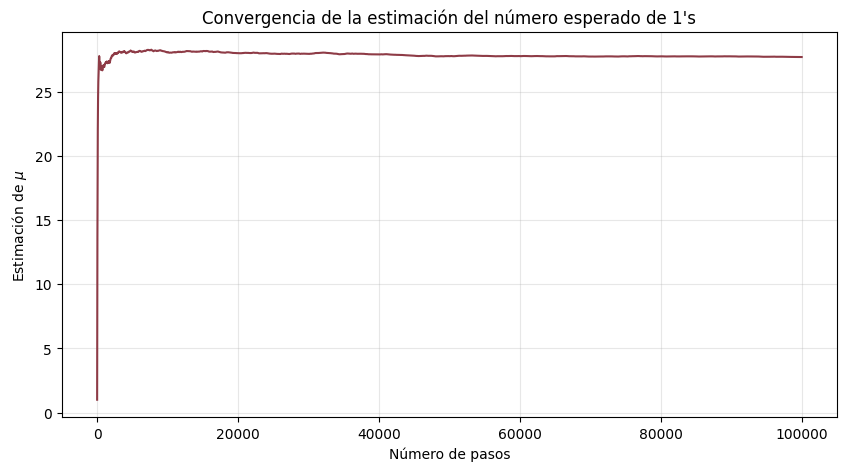

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(range(1, n + 1), estimaciones, color="#8E3B46")

plt.xlabel("Número de pasos")
plt.ylabel(r"Estimación de $\mu$")
plt.title("Convergencia de la estimación del número esperado de 1's")
plt.grid(alpha=0.3)

plt.show()

<h3>
<font color="#B05A67">Observación</font>
</h3>

Al inicio de la caminata la estimación presenta mayores variaciones. Conforme aumenta el número de pasos, el promedio acumulado comienza a estabilizarse.

Este comportamiento permite observar cómo la caminata aleatoria aproxima el número esperado de 1's en una buena cadena.

<h2>
<font color="#B05A67">Comparación del resultado</font>
</h2>

Para cadenas de longitud $m=100$, el libro proporciona como valor exacto del número esperado de 1's:

$$
\mu = 27.7921.
$$

Este valor puede utilizarse como referencia para comparar la aproximación obtenida mediante la caminata aleatoria.

In [18]:
# Valor exacto reportado en el libro para m = 100
mu_exacto = 27.7921

# Estimación obtenida mediante la caminata aleatoria
mu_estimado = estimaciones[-1]

# Diferencia absoluta
diferencia = abs(mu_estimado - mu_exacto)

print("Estimación obtenida:", mu_estimado)
print("Valor exacto:", mu_exacto)
print("Diferencia absoluta:", diferencia)

Estimación obtenida: 27.70934
Valor exacto: 27.7921
Diferencia absoluta: 0.08276000000000039


<h3>
<font color="#B05A67">Observación</font>
</h3>

La estimación obtenida mediante la caminata aleatoria es cercana al valor exacto reportado en el libro para $m=100$.

La pequeña diferencia entre ambos valores es esperada, ya que la estimación se obtiene a partir de una simulación aleatoria con un número finito de pasos. Al realizar nuevamente la simulación, el resultado puede presentar ligeras variaciones.

<h2>
<font color="#B05A67">Comprobación para $m=4$</font>
</h2>

En las notas de clase se considera el caso $m=4$. Las buenas cadenas son

$$
(0000),\ (1000),\ (0100),\ (0010),\ (0001),\ (1010),\ (1001),\ (0101).
$$

Por lo tanto, el número esperado de 1's puede calcularse directamente como

$$
\mu=
\frac{0+1+1+1+1+2+2+2}{8}
=\frac{10}{8}
=1.25.
$$

Este caso permite comprobar el funcionamiento de la caminata aleatoria, ya que la estimación obtenida por simulación debe aproximarse a $1.25$.

In [19]:
# Comprobación para m = 4
m_prueba = 4
n_prueba = 100000

# Estado inicial
X = [0] * m_prueba

total = 0

for paso in range(n_prueba):
    X = caminata(X)
    total += r(X)

# Estimación para m = 4
mu_prueba = total / n_prueba

print("Estimación para m = 4:", mu_prueba)
print("Valor exacto:", 1.25)

Estimación para m = 4: 1.24857
Valor exacto: 1.25


<h3>
<font color="#B05A67">Observación</font>
</h3>

Para $m=4$, la estimación obtenida mediante la caminata aleatoria es cercana al valor exacto

$$
\mu=1.25.
$$

Esto permite comprobar, en un caso donde el resultado puede calcularse directamente, que la caminata aleatoria está generando buenas cadenas y que el promedio de $r(X_n)$ proporciona una aproximación adecuada del número esperado de 1's.

<h2>
<font color="#B05A67">Resultado final</font>
</h2>

Para una buena cadena de longitud

$$
m=100,
$$

se realizó una caminata aleatoria de $100000$ pasos y se estimó el número esperado de 1's mediante

$$
\hat{\mu}=
\frac{r(X_1)+r(X_2)+\cdots+r(X_n)}{n}.
$$

El valor obtenido mediante la simulación se muestra a continuación.

In [20]:
print("Estimación final para m = 100:")
print("μ ≈", round(estimaciones[-1], 4))

Estimación final para m = 100:
μ ≈ 27.7093


<h2>
<font color="#B05A67">Conclusión</font>
</h2>

La caminata aleatoria permitió generar buenas cadenas sin tener que enumerar todas las posibles secuencias de longitud $m=100$. En cada paso se modificó una componente de la cadena, conservando únicamente los cambios que mantienen la condición de no tener 1's adyacentes.

A partir de los estados generados se calculó $r(X_n)$ y, mediante su promedio, se obtuvo una aproximación del número esperado de 1's. La gráfica mostró que la estimación se estabiliza conforme aumenta el número de pasos.

Además, para $m=4$ la simulación produjo un resultado cercano al valor exacto $\mu=1.25$, lo que permitió comprobar el funcionamiento del algoritmo.